In [2]:
import pandas as pd

df = pd.read_csv("./data/DSI_kickstarterscrape_dataset.csv", encoding="latin-1")

print("Number of rows", len(df))
df.head()

Number of rows 45957


,project id,name,url,category,subcategory,location,status,goal,pledged,funded percentage,backers,funded date,levels,reward levels,updates,comments,duration
0,39409,WHILE THE TREES SLEEP,http://www.kickstarter.com/projects/emiliesaba...,Film & Video,Short Film,"Columbia, MO",successful,10500.0,11545.0,1.099524,66,"Fri, 19 Aug 2011 19:28:17 -0000",7,"$25,$50,$100,$250,$500,$1,000,$2,500",10,2,30.00
1,126581,Educational Online Trading Card Game,http://www.kickstarter.com/projects/972789543/...,Games,Board & Card Games,"Maplewood, NJ",failed,4000.0,20.0,0.005000,2,"Mon, 02 Aug 2010 03:59:00 -0000",5,"$1,$5,$10,$25,$50",6,0,47.18
2,138119,STRUM,http://www.kickstarter.com/projects/185476022/...,Film & Video,Animation,"Los Angeles, CA",live,20000.0,56.0,0.002800,3,"Fri, 08 Jun 2012 00:00:31 -0000",10,"$1,$10,$25,$40,$50,$100,$250,$1,000,$1,337,$9,001",1,0,28.00
3,237090,GETTING OVER - One son's search to finally kno...,http://www.kickstarter.com/projects/charnick/g...,Film & Video,Documentary,"Los Angeles, CA",successful,6000.0,6535.0,1.089167,100,"Sun, 08 Apr 2012 02:14:00 -0000",13,"$1,$10,$25,$30,$50,$75,$85,$100,$110,$250,$500...",4,0,32.22
4,246101,The Launch of FlyeGrlRoyalty &quot;The New Nam...,http://www.kickstarter.com/projects/flyegrlroy...,Fashion,Fashion,"Novi, MI",failed,3500.0,0.0,0.000000,0,"Wed, 01 Jun 2011 15:25:39 -0000",6,"$10,$25,$50,$100,$150,$250",2,0,30.00


In [3]:
# Create a histogram that shows the distribution for number of backers. What is the skew of the distribution?

backers_df = df.copy()



In [4]:
# Step 1: Remove any non-numeric 'backers' values

backers_df['backers'] = backers_df['backers'].apply(lambda x: x if isinstance(x, (int, float)) else None)

# Step 2: Drop any rows with missing values

backers_df = backers_df.dropna(subset=['backers'])

# Check if any rows were dropped

print("Has any rows been dropped? ", len(df) != len(backers_df))

Has any rows been dropped?  False


In [5]:
# Step 3: Remove any duplicate rows

backers_df = backers_df.drop_duplicates(subset=["project id"])

print("Number of rows after removing duplicates: ", len(backers_df))

print("Number of duplicates dropped: ", len(df) - len(backers_df))

Number of rows after removing duplicates:  45815
Number of duplicates dropped:  142


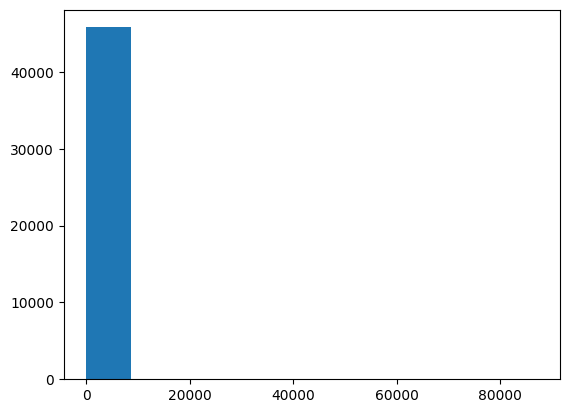

In [ ]:
# Step 4: Plot the distribution of backers
import matplotlib.pyplot as plt

plt.hist(backers_df['backers'])
plt.show()


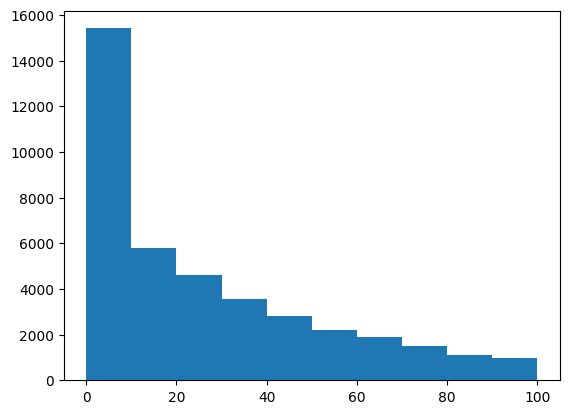

In [ ]:
# from the look of the plot, it seems that the distribution is heavily skewed to the right
# which seems to show a single bar graph

# let's zoom in on the plot by adding a limit to the x-axis to better visualize it

plt.hist(backers_df[backers_df['backers'] <= 100]['backers'])
plt.show()

In [ ]:
# Step 5: Determine whether it is right-skewed, left-skewed, or symmetric

mean = backers_df['backers'].mean()
median = backers_df['backers'].median()

print("Mean: ", mean)
print("Median: ", median)

if mean > median:
    print("The distribution is right-skewed")
elif mean < median:
    print("The distribution is left-skewed")
else:
    print("The distribution is symmetric")


Mean:  70.04216959511078
Median:  23.0
The distribution is right-skewed


In [27]:
# Step 6: Calculate the skewness of the distribution

skewness = backers_df['backers'].skew()

print("Skewness: ", skewness)



Skewness:  87.34231843601833
